Projected First-Week Global Streams for 'Iceman': 553 Million


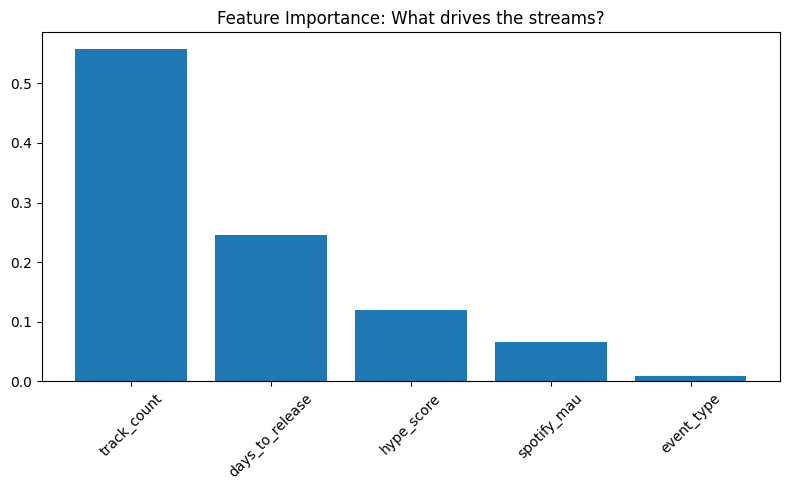

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Setup the data
csv_content = """album,track_count,spotify_mau,hype_score,days_to_release,event_type,first_week_streams
Divide,16,120,9,21,0,375
Scorpion,25,207,9,7,1,559
Astroworld,17,207,9,14,0,350
AfterHours,14,299,9,21,0,450
Justice,16,406,8,14,0,252
Midnights,20,489,10,21,0,776
SOS,23,489,9,21,0,400
Utopia,19,574,8,14,0,455
1989TV,21,574,9,21,0,600
TTPD,31,640,10,28,0,1173
HUT,22,640,10,21,0,580
ShortNSweet,12,640,8,21,0,450
GNX,12,640,10,7,1,363"""

with open('albums.csv', 'w') as f:
    f.write(csv_content)

df = pd.read_csv('albums.csv')

# 2. Train the Model
features = ['track_count', 'spotify_mau', 'hype_score', 'days_to_release', 'event_type']
X = df[features]
y = df['first_week_streams']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# 3. Predict & Visualize
iceman_input = pd.DataFrame([[22, 751, 9.5, 21, 0]], columns=features)
prediction = model.predict(iceman_input)
print(f"Projected First-Week Global Streams for 'Iceman': {prediction[0]:,.0f} Million")

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
plt.title("Feature Importance: What drives the streams?")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

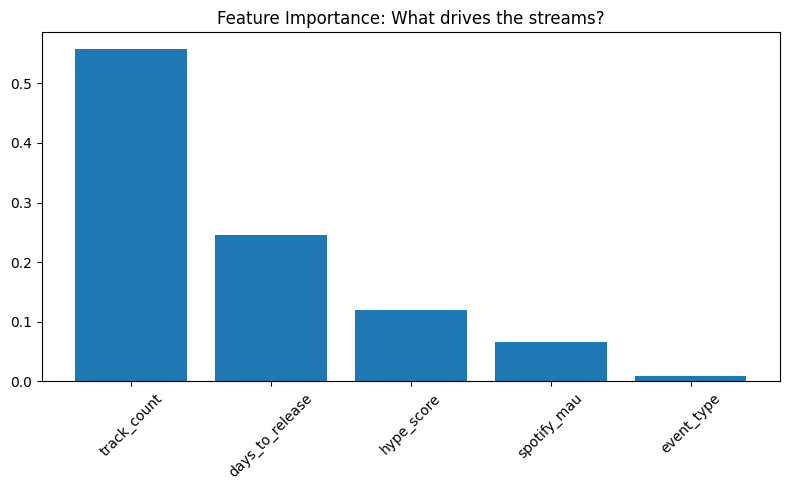

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Get importance values from the trained model
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the results
plt.figure(figsize=(8, 5))
plt.title("Feature Importance: What drives the streams?")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()